# Complex Multivariate Time Series Generation
## 复杂多变量时间序列生成

This notebook generates more complex multivariate relationships to address reviewer concerns about oversimplified cross-variable evaluation.

Generated datasets include:
1. **Nonlinear Relationship**: Y(t) = a * sin(b * X(t-k)) + noise
2. **Conditional Relationship**: Binary relationship based on threshold conditions
3. **Multi-variable Complex Interactions**: Five variables with complex interdependencies

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import signal
import seaborn as sns

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 1. Nonlinear Relationship Dataset
### 非线性关系数据集

**Design**: Y(t) = a * sin(b * X(t-k)) + noise  
- X: White noise  
- Y: Nonlinear transformation of lagged X (k=48)  
- Parameters: a=2.0, b=0.5

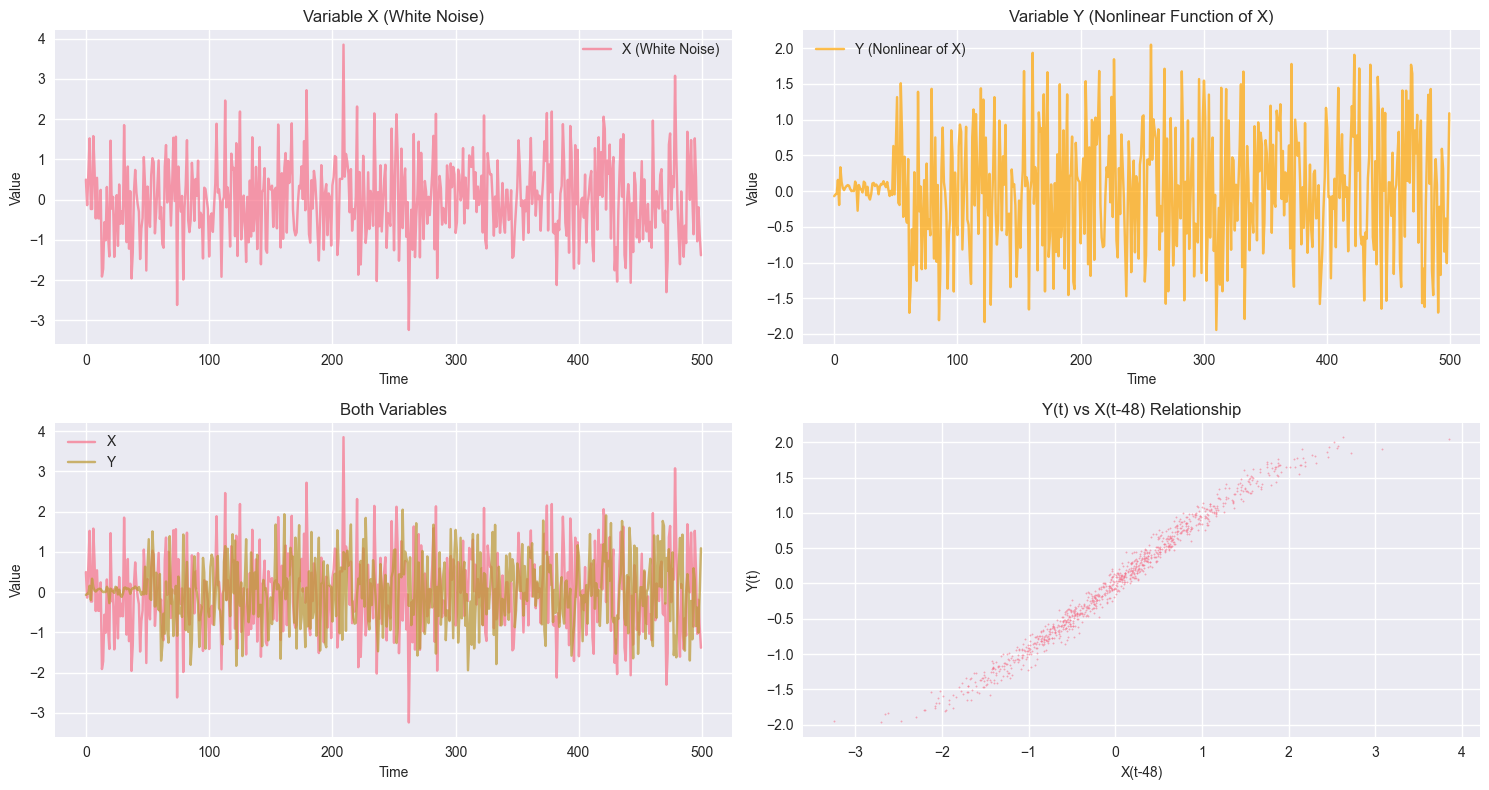

Correlation between X(t-48) and Y(t): 0.9881


In [2]:
def generate_nonlinear_relationship(n, lag=48, a=2.0, b=0.5, noise_std=0.1, x_noise_std=1.0):
    """
    Generate nonlinear relationship dataset:
    X(t): White noise
    Y(t) = a * sin(b * X(t-lag)) + noise
    
    Parameters:
    n (int): Length of the time series
    lag (int): Lag between X and Y (default: 48)
    a (float): Amplitude scaling factor (default: 2.0)
    b (float): Frequency scaling factor (default: 0.5)
    noise_std (float): Standard deviation of noise added to Y
    x_noise_std (float): Standard deviation of white noise for X
    
    Returns:
    tuple: (X, Y) - Two numpy arrays representing the variables
    """
    # Generate X as white noise
    X = np.random.normal(0, x_noise_std, n)
    
    # Initialize Y
    Y = np.zeros(n)
    
    # Generate Y based on nonlinear transformation of lagged X
    for t in range(lag, n):
        Y[t] = a * np.sin(b * X[t - lag]) + np.random.normal(0, noise_std)
    
    # For the first 'lag' points, use mean of later values plus noise
    mean_y = np.mean(Y[lag:])
    Y[:lag] = np.random.normal(mean_y, noise_std, lag)
    
    return X, Y

# Test the function and visualize
np.random.seed(42)
X_test, Y_test = generate_nonlinear_relationship(1000)

# Plot the relationship
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.plot(X_test[:500], label='X (White Noise)', alpha=0.7)
plt.title('Variable X (White Noise)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(Y_test[:500], label='Y (Nonlinear of X)', alpha=0.7, color='orange')
plt.title('Variable Y (Nonlinear Function of X)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(X_test[:500], alpha=0.7, label='X')
plt.plot(Y_test[:500], alpha=0.7, label='Y')
plt.title('Both Variables')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

# Scatter plot to show relationship
plt.subplot(2, 2, 4)
# Use X(t-48) vs Y(t) to show the relationship
plt.scatter(X_test[:-48], Y_test[48:], alpha=0.5, s=1)
plt.title('Y(t) vs X(t-48) Relationship')
plt.xlabel('X(t-48)')
plt.ylabel('Y(t)')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Correlation between X(t-48) and Y(t): {np.corrcoef(X_test[:-48], Y_test[48:])[0,1]:.4f}")

## 2. Conditional Relationship Dataset
### 条件性关系数据集

**Design**: Binary conditional relationship  
- X: White noise  
- Y: Binary variable (0 or 1) based on threshold condition  
- Rule: Y(t) = 1 if X(t-48) > threshold, else Y(t) = 0

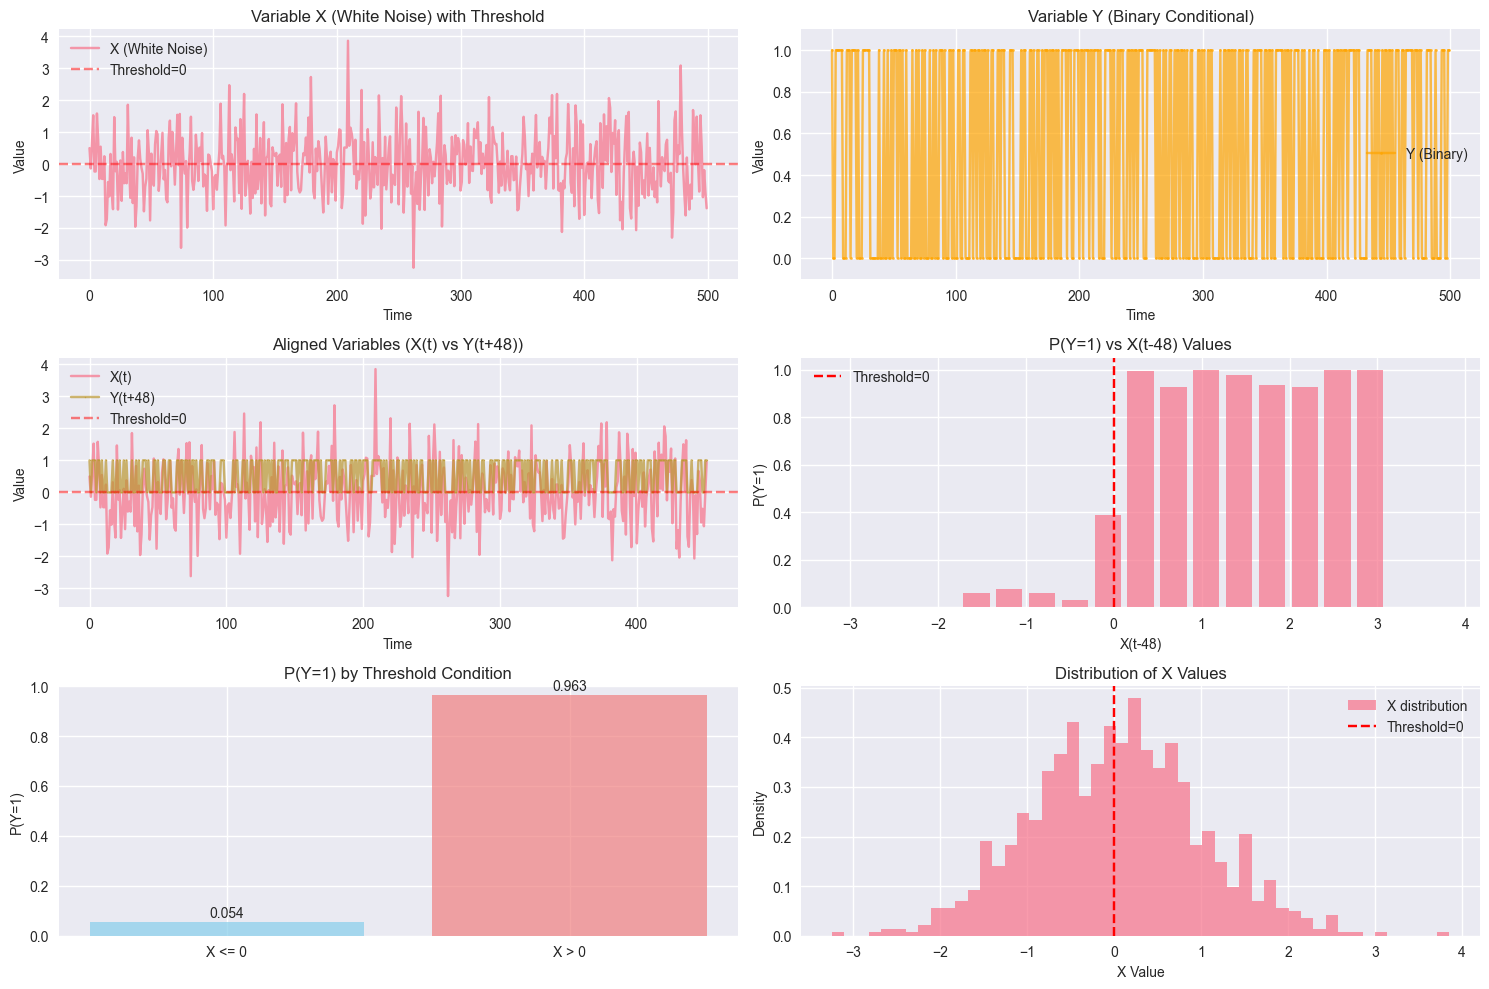

Proportion of Y=1 when X(t-48) > 0: 0.9630
Proportion of Y=1 when X(t-48) <= 0: 0.0536
Overall proportion of Y=1: 0.5170


In [3]:
def generate_conditional_relationship(n, lag=48, threshold=0.0, x_noise_std=1.0, noise_prob=0.05):
    """
    Generate conditional relationship dataset:
    X(t): White noise
    Y(t) = 1 if X(t-lag) > threshold, else 0 (with small probability of noise)
    
    Parameters:
    n (int): Length of the time series
    lag (int): Lag between X and Y (default: 48)
    threshold (float): Threshold for conditional relationship (default: 0.0)
    x_noise_std (float): Standard deviation of white noise for X
    noise_prob (float): Probability of flipping the binary decision (adds noise)
    
    Returns:
    tuple: (X, Y) - Two numpy arrays representing the variables
    """
    # Generate X as white noise
    X = np.random.normal(0, x_noise_std, n)
    
    # Initialize Y
    Y = np.zeros(n)
    
    # Generate Y based on conditional relationship with lagged X
    for t in range(lag, n):
        # Basic conditional rule
        if X[t - lag] > threshold:
            Y[t] = 1
        else:
            Y[t] = 0
        
        # Add noise: randomly flip the decision with small probability
        if np.random.random() < noise_prob:
            Y[t] = 1 - Y[t]
    
    # For the first 'lag' points, use random binary values
    Y[:lag] = np.random.choice([0, 1], size=lag, p=[0.5, 0.5])
    
    return X, Y

# Test the function and visualize
np.random.seed(42)
X_cond, Y_cond = generate_conditional_relationship(1000)

# Plot the relationship
plt.figure(figsize=(15, 10))

plt.subplot(3, 2, 1)
plt.plot(X_cond[:500], label='X (White Noise)', alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Threshold=0')
plt.title('Variable X (White Noise) with Threshold')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 2)
plt.plot(Y_cond[:500], label='Y (Binary)', alpha=0.7, color='orange', marker='o', markersize=2)
plt.title('Variable Y (Binary Conditional)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 3)
# Show both with lag alignment
plt.plot(X_cond[:452], alpha=0.7, label='X(t)')
plt.plot(Y_cond[48:500], alpha=0.7, label='Y(t+48)', marker='o', markersize=1)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Threshold=0')
plt.title('Aligned Variables (X(t) vs Y(t+48))')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

# Analysis of conditional relationship
plt.subplot(3, 2, 4)
# Create bins for X values and calculate Y probability in each bin
x_lagged = X_cond[:-48]
y_future = Y_cond[48:]

# Create bins
bins = np.linspace(x_lagged.min(), x_lagged.max(), 20)
bin_centers = (bins[:-1] + bins[1:]) / 2
prob_y_1 = []

for i in range(len(bins)-1):
    mask = (x_lagged >= bins[i]) & (x_lagged < bins[i+1])
    if np.sum(mask) > 0:
        prob_y_1.append(np.mean(y_future[mask]))
    else:
        prob_y_1.append(0)

plt.bar(bin_centers, prob_y_1, width=(bins[1]-bins[0])*0.8, alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', label='Threshold=0')
plt.title('P(Y=1) vs X(t-48) Values')
plt.xlabel('X(t-48)')
plt.ylabel('P(Y=1)')
plt.legend()
plt.grid(True)

# Confusion matrix style analysis
plt.subplot(3, 2, 5)
above_threshold = x_lagged > 0
below_threshold = x_lagged <= 0

prob_y1_above = np.mean(y_future[above_threshold])
prob_y1_below = np.mean(y_future[below_threshold])

categories = ['X <= 0', 'X > 0']
probabilities = [prob_y1_below, prob_y1_above]

plt.bar(categories, probabilities, alpha=0.7, color=['skyblue', 'lightcoral'])
plt.title('P(Y=1) by Threshold Condition')
plt.ylabel('P(Y=1)')
plt.ylim(0, 1)
for i, v in enumerate(probabilities):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.grid(True)

plt.subplot(3, 2, 6)
# Distribution of X values
plt.hist(X_cond, bins=50, alpha=0.7, density=True, label='X distribution')
plt.axvline(x=0, color='red', linestyle='--', label='Threshold=0')
plt.title('Distribution of X Values')
plt.xlabel('X Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Proportion of Y=1 when X(t-48) > 0: {prob_y1_above:.4f}")
print(f"Proportion of Y=1 when X(t-48) <= 0: {prob_y1_below:.4f}")
print(f"Overall proportion of Y=1: {np.mean(Y_cond):.4f}")

## 3. Multi-variable Complex Interactions Dataset
### 多变量复杂交互数据集

**Design**: Five variables with complex interdependencies  
- V1: White noise (base variable)  
- V2: Lagged linear transformation of V1  
- V3: Nonlinear function of V1 and V2  
- V4: Conditional relationship based on V2  
- V5: Complex interaction of V1, V3, and V4

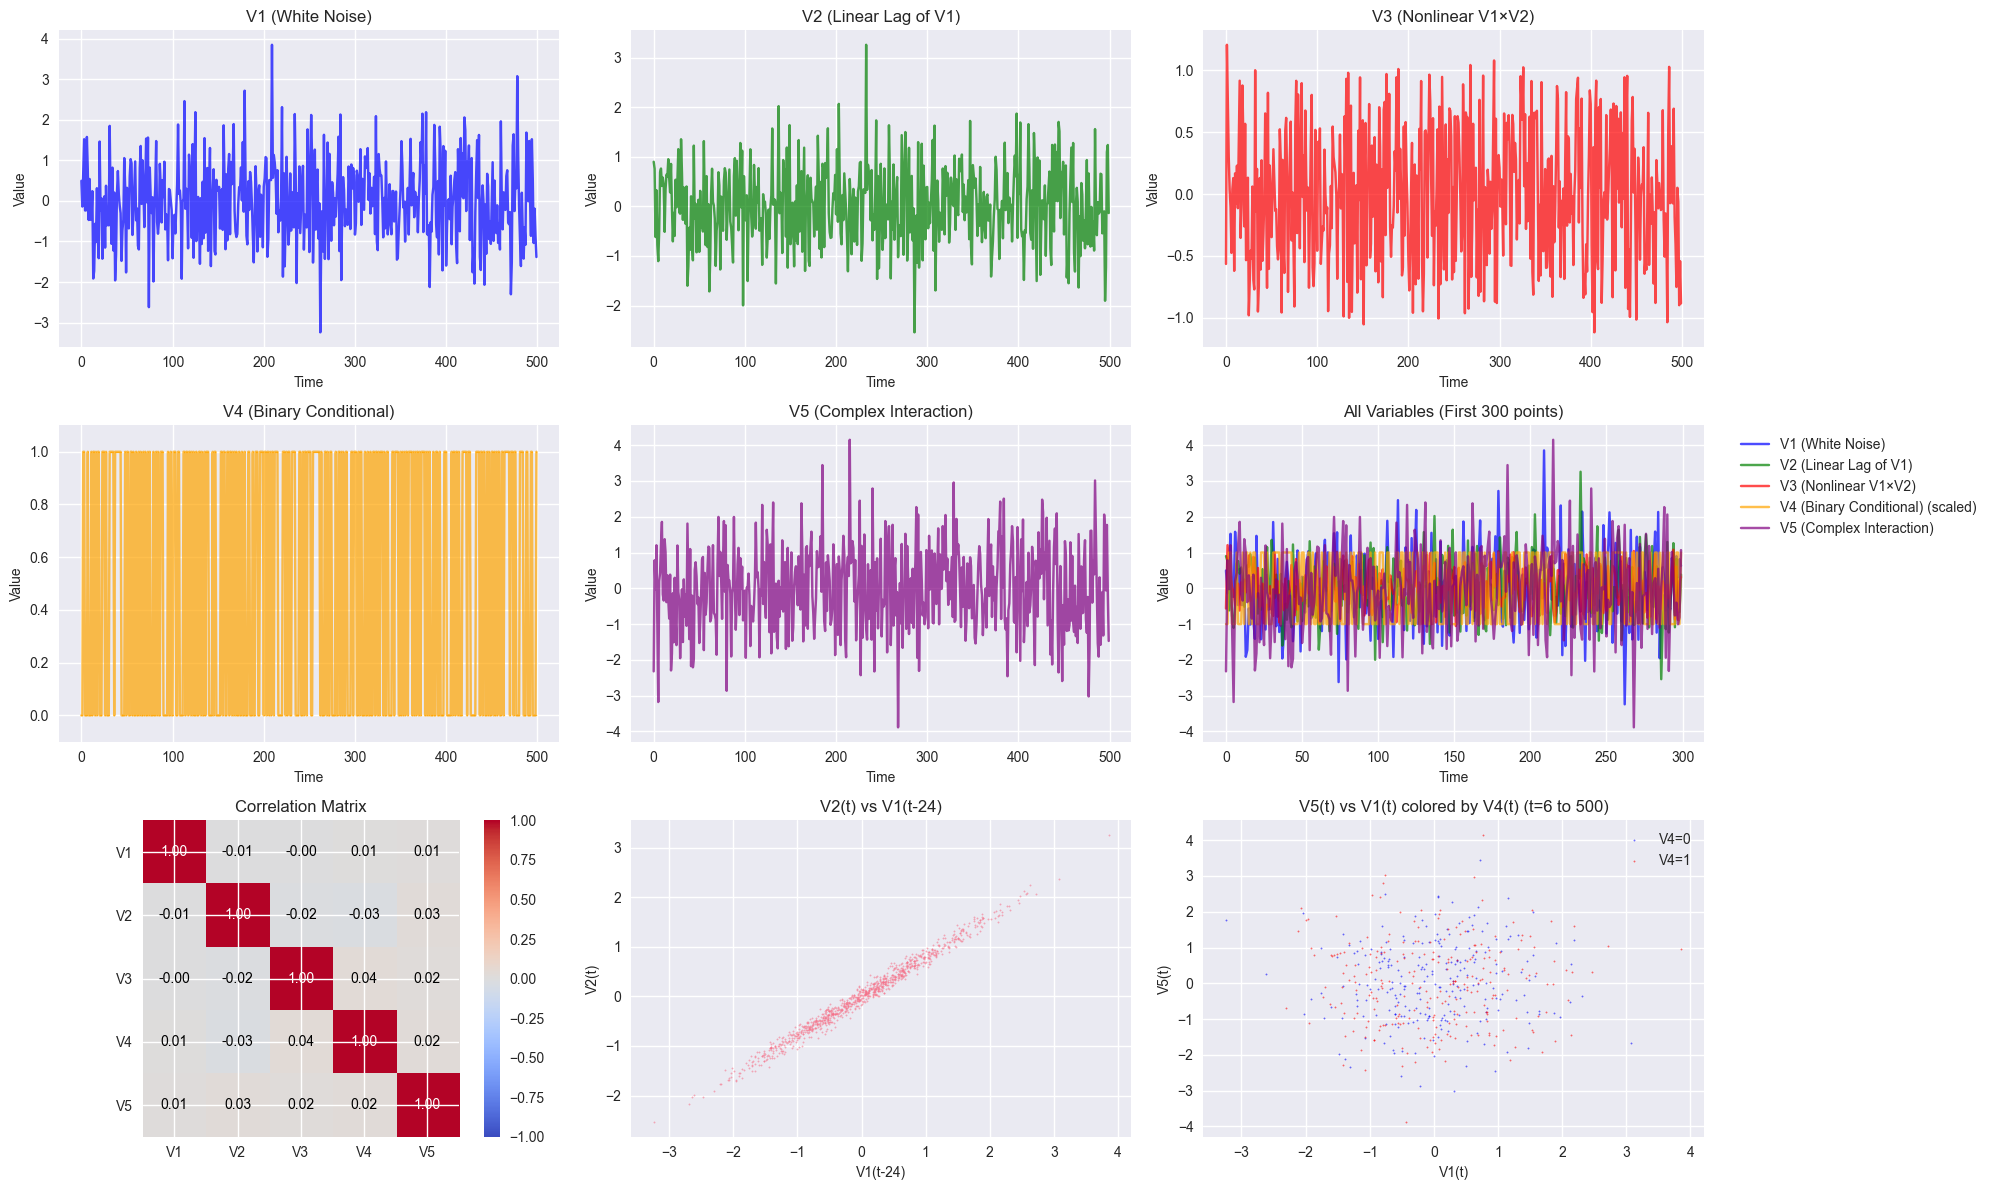


Variable Statistics:
V1: Mean=0.0193, Std=0.9787, Min=-3.2413, Max=3.8527
V2: Mean=0.0294, Std=0.7813, Min=-2.5391, Max=3.2571
V3: Mean=0.0127, Std=0.5410, Min=-1.1246, Max=1.2058
V4: Mean=0.4970, Std=0.5000, Min=0.0000, Max=1.0000
V5: Mean=0.0184, Std=1.1568, Min=-3.8847, Max=4.1501


In [4]:
def generate_multivariable_complex(n, lag1=24, lag2=48, noise_std=0.1):
    """
    Generate complex multi-variable dataset with five interdependent variables:
    
    V1(t): White noise (base variable)
    V2(t): 0.8 * V1(t-24) + noise (linear lagged relationship)
    V3(t): sin(V1(t-12)) * cos(V2(t-12)) + noise (nonlinear interaction)
    V4(t): Binary variable based on V2(t-24) > median(V2) (conditional)
    V5(t): V1(t-6) + 0.5 * V3(t-6) + V4(t-6) * sign(V1(t-6)) + noise (complex interaction)
    
    Parameters:
    n (int): Length of the time series
    lag1 (int): First lag parameter (default: 24)
    lag2 (int): Second lag parameter (default: 48)
    noise_std (float): Standard deviation of noise terms
    
    Returns:
    tuple: (V1, V2, V3, V4, V5) - Five numpy arrays representing the variables
    """
    # Initialize all variables
    V1 = np.random.normal(0, 1, n)  # White noise
    V2 = np.zeros(n)
    V3 = np.zeros(n)
    V4 = np.zeros(n)
    V5 = np.zeros(n)
    
    # Generate V2: Linear lagged relationship with V1
    for t in range(lag1, n):
        V2[t] = 0.8 * V1[t - lag1] + np.random.normal(0, noise_std)
    
    # Fill initial values for V2
    V2[:lag1] = np.random.normal(0, 0.8, lag1)
    
    # Generate V3: Nonlinear interaction between V1 and V2
    lag_12 = 12
    for t in range(lag_12, n):
        V3[t] = np.sin(V1[t - lag_12]) * np.cos(V2[t - lag_12]) + np.random.normal(0, noise_std)
    
    # Fill initial values for V3
    V3[:lag_12] = np.random.normal(0, 0.5, lag_12)
    
    # Calculate median of V2 for conditional relationship
    v2_median = np.median(V2)
    
    # Generate V4: Binary conditional based on V2
    for t in range(lag1, n):
        if V2[t - lag1] > v2_median:
            V4[t] = 1
        else:
            V4[t] = 0
        
        # Add small amount of noise (5% chance of flip)
        if np.random.random() < 0.05:
            V4[t] = 1 - V4[t]
    
    # Fill initial values for V4
    V4[:lag1] = np.random.choice([0, 1], size=lag1)
    
    # Generate V5: Complex interaction of V1, V3, and V4
    lag_6 = 6
    for t in range(lag_6, n):
        # Base component: V1(t-6) + 0.5 * V3(t-6)
        base = V1[t - lag_6] + 0.5 * V3[t - lag_6]
        
        # Conditional component: V4(t-6) modulates the sign effect
        conditional = V4[t - lag_6] * np.sign(V1[t - lag_6]) * 0.3
        
        V5[t] = base + conditional + np.random.normal(0, noise_std)
    
    # Fill initial values for V5
    V5[:lag_6] = np.random.normal(0, 1, lag_6)
    
    return V1, V2, V3, V4, V5

# Test the function and visualize
np.random.seed(42)
V1, V2, V3, V4, V5 = generate_multivariable_complex(1000)

# Plot all variables
plt.figure(figsize=(20, 12))

variables = [V1, V2, V3, V4, V5]
var_names = ['V1 (White Noise)', 'V2 (Linear Lag of V1)', 'V3 (Nonlinear V1×V2)', 
             'V4 (Binary Conditional)', 'V5 (Complex Interaction)']
colors = ['blue', 'green', 'red', 'orange', 'purple']

# Individual plots
for i in range(5):
    plt.subplot(3, 3, i+1)
    if i == 3:  # V4 is binary
        plt.plot(variables[i][:500], marker='o', markersize=1, alpha=0.7, color=colors[i])
        plt.ylim(-0.1, 1.1)
    else:
        plt.plot(variables[i][:500], alpha=0.7, color=colors[i])
    plt.title(var_names[i])
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.grid(True)

# Combined plot
plt.subplot(3, 3, 6)
for i in range(5):
    if i == 3:  # Scale V4 for visibility
        plt.plot(variables[i][:300] * 2 - 1, alpha=0.7, label=f'{var_names[i]} (scaled)', color=colors[i])
    else:
        plt.plot(variables[i][:300], alpha=0.7, label=var_names[i], color=colors[i])
plt.title('All Variables (First 300 points)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# Correlation matrix
plt.subplot(3, 3, 7)
corr_matrix = np.corrcoef([V1, V2, V3, V4, V5])
im = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)
plt.title('Correlation Matrix')
plt.xticks(range(5), ['V1', 'V2', 'V3', 'V4', 'V5'])
plt.yticks(range(5), ['V1', 'V2', 'V3', 'V4', 'V5'])

# Add correlation values
for i in range(5):
    for j in range(5):
        plt.text(j, i, f'{corr_matrix[i,j]:.2f}', ha='center', va='center', 
                color='white' if abs(corr_matrix[i,j]) > 0.5 else 'black')

# Scatter plots showing relationships
plt.subplot(3, 3, 8)
plt.scatter(V1[:-24], V2[24:], alpha=0.5, s=1)
plt.title('V2(t) vs V1(t-24)')
plt.xlabel('V1(t-24)')
plt.ylabel('V2(t)')
plt.grid(True)

plt.subplot(3, 3, 9)
# Show V5 vs V1 with V4 color coding - Fix the dimension mismatch
# Ensure all arrays have the same length
end_idx = 500
lag_6 = 6
V1_slice = V1[lag_6:end_idx]
V4_slice = V4[lag_6:end_idx]  
V5_slice = V5[lag_6:end_idx]

mask_v4_0 = V4_slice == 0
mask_v4_1 = V4_slice == 1
plt.scatter(V1_slice[mask_v4_0], V5_slice[mask_v4_0], alpha=0.5, s=1, label='V4=0', color='blue')
plt.scatter(V1_slice[mask_v4_1], V5_slice[mask_v4_1], alpha=0.5, s=1, label='V4=1', color='red')
plt.title('V5(t) vs V1(t) colored by V4(t) (t=6 to 500)')
plt.xlabel('V1(t)')
plt.ylabel('V5(t)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nVariable Statistics:")
for i, name in enumerate(['V1', 'V2', 'V3', 'V4', 'V5']):
    var = variables[i]
    print(f"{name}: Mean={np.mean(var):.4f}, Std={np.std(var):.4f}, Min={np.min(var):.4f}, Max={np.max(var):.4f}")

## 4. Dataset Generation and Saving Functions
### 数据集生成和保存函数

In [5]:
def save_multivariate_signal(signals, feature_names, folder, signal_name, dataset_id=None, category=None, length=None):
    """
    Save multivariate signals to CSV file
    
    Parameters:
    signals (list): List of signal arrays, each representing a feature
    feature_names (list): Feature names corresponding to signals
    folder (str): Base folder to save to
    signal_name (str): Signal name
    dataset_id (int, optional): Dataset ID
    category (str, optional): Category (e.g., raw, processed)
    length (int, optional): Signal length
    """
    if not os.path.exists(folder):
        os.makedirs(folder)
    
    # Build filename
    filename = signal_name
    if dataset_id is not None:
        filename = f"dataset{dataset_id}_{filename}"
    if category is not None:
        filename = f"{filename}_{category}"
    if length is not None:
        filename = f"{filename}_length{length}"
    
    # Create timestamp column
    timestamps = np.arange(len(signals[0]))
    
    # Create DataFrame with all features
    data = {'date': timestamps}
    for i, (signal, feature_name) in enumerate(zip(signals, feature_names)):
        data[feature_name] = signal
    
    df = pd.DataFrame(data)
    
    # Save as CSV
    df.to_csv(os.path.join(folder, f"{filename}.csv"), index=False)
    print(f"Saved: {os.path.join(folder, f'{filename}.csv')}")

def generate_and_save_complex_datasets(seed, dataset_folder, dataset_id, n=5000):
    """
    Generate and save complex multivariate time series datasets
    """
    np.random.seed(seed)
    
    print(f"\nGenerating Dataset {dataset_id} with seed {seed}...")
    
    # 1. Nonlinear Relationship Dataset
    print("Generating Nonlinear Relationship Dataset...")
    X_nonlin, Y_nonlin = generate_nonlinear_relationship(n)
    save_multivariate_signal(
        [X_nonlin, Y_nonlin],
        ["X_WhiteNoise", "Y_NonlinearSin"],
        dataset_folder, "NonlinearRelationship", dataset_id, "raw", n
    )
    
    # 2. Conditional Relationship Dataset
    print("Generating Conditional Relationship Dataset...")
    X_cond, Y_cond = generate_conditional_relationship(n)
    save_multivariate_signal(
        [X_cond, Y_cond],
        ["X_WhiteNoise", "Y_BinaryConditional"],
        dataset_folder, "ConditionalRelationship", dataset_id, "raw", n
    )
    
    # 3. Multi-variable Complex Interactions Dataset
    print("Generating Multi-variable Complex Interactions Dataset...")
    V1, V2, V3, V4, V5 = generate_multivariable_complex(n)
    save_multivariate_signal(
        [V1, V2, V3, V4, V5],
        ["V1_WhiteNoise", "V2_LinearLag", "V3_NonlinearInteraction", "V4_BinaryConditional", "V5_ComplexInteraction"],
        dataset_folder, "MultivariableComplex", dataset_id, "raw", n
    )
    
    print(f"Dataset {dataset_id} generation completed.")

def generate_multiple_complex_datasets(num_datasets=5, seed=None):
    """
    Generate multiple complex multivariate datasets
    """
    output_folder = "Dataset_generated_complex_multivariate"
    
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    print(f"Generating {num_datasets} complex multivariate datasets...")
    
    for i in range(num_datasets):
        # Use provided seed for the first dataset, then generate random seeds for others
        current_seed = seed if i == 0 and seed is not None else np.random.randint(0, 2**16)
        generate_and_save_complex_datasets(current_seed, output_folder, i+1)
    
    print(f"\nAll {num_datasets} datasets generated successfully!")
    print(f"Saved to folder: {output_folder}")

## 5. Generate Datasets
### 生成数据集

In [8]:
# Generate 1 dataset with the specific seed used for evaluation
generate_multiple_complex_datasets(num_datasets=1, seed=59117)

Generating 1 complex multivariate datasets...

Generating Dataset 1 with seed 59117...
Generating Nonlinear Relationship Dataset...
Saved: Dataset_generated_complex_multivariate/dataset1_NonlinearRelationship_raw_length5000.csv
Generating Conditional Relationship Dataset...
Saved: Dataset_generated_complex_multivariate/dataset1_ConditionalRelationship_raw_length5000.csv
Generating Multi-variable Complex Interactions Dataset...
Saved: Dataset_generated_complex_multivariate/dataset1_MultivariableComplex_raw_length5000.csv
Dataset 1 generation completed.

All 1 datasets generated successfully!
Saved to folder: Dataset_generated_complex_multivariate


## 6. Theoretical Optimal Metrics Calculation
### 理论最优指标计算

Calculate theoretical optimal MSE and MAE for the generated complex datasets to establish benchmarks.

In [10]:
from sklearn.preprocessing import StandardScaler

def calculate_optimal_metrics_nonlinear(folder_path="Dataset_generated_complex_multivariate", 
                                       dataset_id=1,
                                       test_ratio=0.2, 
                                       input_window=96,
                                       prediction_window=96,
                                       lag=48, a=2.0, b=0.5):
    """
    Calculate theoretical optimal MSE and MAE for Nonlinear Relationship datasets.
    Uses data normalization and sliding window prediction (step=1).
    Correctly handles lag constraints - only uses available past information.
    """
    results = {}
    file_path = os.path.join(folder_path, f"dataset{dataset_id}_NonlinearRelationship_raw_length5000.csv")
    
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return results
    
    df = pd.read_csv(file_path)
    X = df["X_WhiteNoise"].values
    Y = df["Y_NonlinearSin"].values
    
    # Data splitting (train: 70%, val: 10%, test: 20%)
    total_length = len(X)
    num_train = int(total_length * 0.7)
    test_start = total_length - int(total_length * test_ratio)
    
    # Normalize each variable separately using training data
    scaler_X = StandardScaler()
    scaler_Y = StandardScaler()
    
    X_reshaped = X.reshape(-1, 1)
    Y_reshaped = Y.reshape(-1, 1)
    
    scaler_X.fit(X_reshaped[:num_train])
    scaler_Y.fit(Y_reshaped[:num_train])
    
    X_normalized = scaler_X.transform(X_reshaped).flatten()
    Y_normalized = scaler_Y.transform(Y_reshaped).flatten()
    
    # Sliding window prediction with step=1
    all_X_predictions = []
    all_Y_predictions = []
    all_X_actuals = []
    all_Y_actuals = []
    
    for i in range(test_start, total_length - prediction_window + 1):
        # Get actual normalized values for this window
        actual_X = X_normalized[i:i+prediction_window]
        actual_Y = Y_normalized[i:i+prediction_window]
        
        # Generate optimal predictions
        # For X (white noise): best prediction is training mean
        pred_X = np.full(prediction_window, np.mean(X_normalized[:num_train]))
        
        # For Y: use known generative function BUT only when we have past X information
        pred_Y_raw = np.zeros(prediction_window)
        for t in range(prediction_window):
            prediction_time = i + t
            # We can only use X values that are available at prediction time
            # For Y(t) = f(X(t-lag)), we need X(t-lag) to be in the past or present
            required_X_time = prediction_time - lag
            
            if required_X_time < i:
                # We have the required X information (it's in the past)
                pred_Y_raw[t] = a * np.sin(b * X[required_X_time])
            else:
                # We don't have the required X information (it's in the future prediction window)
                # Use training mean as best estimate
                pred_Y_raw[t] = np.mean(Y[:num_train])
        
        # Normalize the raw prediction
        pred_Y = scaler_Y.transform(pred_Y_raw.reshape(-1, 1)).flatten()
        
        all_X_predictions.append(pred_X)
        all_Y_predictions.append(pred_Y)
        all_X_actuals.append(actual_X)
        all_Y_actuals.append(actual_Y)
    
    # Convert to arrays and calculate metrics
    all_X_predictions = np.array(all_X_predictions)
    all_Y_predictions = np.array(all_Y_predictions)
    all_X_actuals = np.array(all_X_actuals)
    all_Y_actuals = np.array(all_Y_actuals)
    
    X_mse = mean_squared_error(all_X_actuals.flatten(), all_X_predictions.flatten())
    X_mae = mean_absolute_error(all_X_actuals.flatten(), all_X_predictions.flatten())
    Y_mse = mean_squared_error(all_Y_actuals.flatten(), all_Y_predictions.flatten())
    Y_mae = mean_absolute_error(all_Y_actuals.flatten(), all_Y_predictions.flatten())
    
    avg_mse = (X_mse + Y_mse) / 2
    avg_mae = (X_mae + Y_mae) / 2
    
    results["NonlinearRelationship"] = {
        "X_MSE": X_mse, "X_MAE": X_mae,
        "Y_MSE": Y_mse, "Y_MAE": Y_mae,
        "Average_MSE": avg_mse, "Average_MAE": avg_mae
    }
    return results

def calculate_optimal_metrics_conditional(folder_path="Dataset_generated_complex_multivariate", 
                                        dataset_id=1,
                                        test_ratio=0.2, 
                                        input_window=96,
                                        prediction_window=96,
                                        lag=48, threshold=0.0):
    """
    Calculate theoretical optimal MSE and MAE for Conditional Relationship datasets.
    Uses data normalization and sliding window prediction (step=1).
    Correctly handles lag constraints - only uses available past information.
    """
    results = {}
    file_path = os.path.join(folder_path, f"dataset{dataset_id}_ConditionalRelationship_raw_length5000.csv")
    
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return results
        
    df = pd.read_csv(file_path)
    X = df["X_WhiteNoise"].values
    Y = df["Y_BinaryConditional"].values
    
    # Data splitting
    total_length = len(X)
    num_train = int(total_length * 0.7)
    test_start = total_length - int(total_length * test_ratio)
    
    # Normalize each variable separately using training data
    scaler_X = StandardScaler()
    scaler_Y = StandardScaler()
    
    X_reshaped = X.reshape(-1, 1)
    Y_reshaped = Y.reshape(-1, 1)
    
    scaler_X.fit(X_reshaped[:num_train])
    scaler_Y.fit(Y_reshaped[:num_train])
    
    X_normalized = scaler_X.transform(X_reshaped).flatten()
    Y_normalized = scaler_Y.transform(Y_reshaped).flatten()
    
    # Sliding window prediction with step=1
    all_X_predictions = []
    all_Y_predictions = []
    all_X_actuals = []
    all_Y_actuals = []
    
    for i in range(test_start, total_length - prediction_window + 1):
        # Get actual normalized values for this window
        actual_X = X_normalized[i:i+prediction_window]
        actual_Y = Y_normalized[i:i+prediction_window]
        
        # Generate optimal predictions
        # For X (white noise): best prediction is training mean
        pred_X = np.full(prediction_window, np.mean(X_normalized[:num_train]))
        
        # For Y: use known conditional rule BUT only when we have past X information
        pred_Y_raw = np.zeros(prediction_window)
        for t in range(prediction_window):
            prediction_time = i + t
            # We can only use X values that are available at prediction time
            # For Y(t) = f(X(t-lag)), we need X(t-lag) to be in the past or present
            required_X_time = prediction_time - lag
            
            if required_X_time < i:
                # We have the required X information (it's in the past)
                pred_Y_raw[t] = 1 if X[required_X_time] > threshold else 0
            else:
                # We don't have the required X information (it's in the future prediction window)
                # Use training mean as best estimate
                pred_Y_raw[t] = np.mean(Y[:num_train])
        
        # Normalize the raw prediction
        pred_Y = scaler_Y.transform(pred_Y_raw.reshape(-1, 1)).flatten()
        
        all_X_predictions.append(pred_X)
        all_Y_predictions.append(pred_Y)
        all_X_actuals.append(actual_X)
        all_Y_actuals.append(actual_Y)
    
    # Convert to arrays and calculate metrics
    all_X_predictions = np.array(all_X_predictions)
    all_Y_predictions = np.array(all_Y_predictions)
    all_X_actuals = np.array(all_X_actuals)
    all_Y_actuals = np.array(all_Y_actuals)
    
    X_mse = mean_squared_error(all_X_actuals.flatten(), all_X_predictions.flatten())
    X_mae = mean_absolute_error(all_X_actuals.flatten(), all_X_predictions.flatten())
    Y_mse = mean_squared_error(all_Y_actuals.flatten(), all_Y_predictions.flatten())
    Y_mae = mean_absolute_error(all_Y_actuals.flatten(), all_Y_predictions.flatten())
    
    avg_mse = (X_mse + Y_mse) / 2
    avg_mae = (X_mae + Y_mae) / 2
    
    results["ConditionalRelationship"] = {
        "X_MSE": X_mse, "X_MAE": X_mae,
        "Y_MSE": Y_mse, "Y_MAE": Y_mae,
        "Average_MSE": avg_mse, "Average_MAE": avg_mae
    }
    return results

def calculate_optimal_metrics_multivariable(folder_path="Dataset_generated_complex_multivariate", 
                                          dataset_id=1,
                                          test_ratio=0.2, 
                                          input_window=96,
                                          prediction_window=96):
    """
    Calculate theoretical optimal MSE and MAE for Multivariable Complex datasets.
    Uses data normalization and sliding window prediction (step=1).
    Correctly handles lag constraints - only uses available past information.
    """
    results = {}
    file_path = os.path.join(folder_path, f"dataset{dataset_id}_MultivariableComplex_raw_length5000.csv")
    
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return results
        
    df = pd.read_csv(file_path)
    V1 = df["V1_WhiteNoise"].values
    V2 = df["V2_LinearLag"].values
    V3 = df["V3_NonlinearInteraction"].values
    V4 = df["V4_BinaryConditional"].values
    V5 = df["V5_ComplexInteraction"].values
    
    all_vars = [V1, V2, V3, V4, V5]
    var_names = ["V1", "V2", "V3", "V4", "V5"]
    
    # Data splitting
    total_length = len(V1)
    num_train = int(total_length * 0.7)
    test_start = total_length - int(total_length * test_ratio)
    
    # Normalize each variable separately using training data
    scalers = []
    vars_normalized = []
    
    for var in all_vars:
        scaler = StandardScaler()
        var_reshaped = var.reshape(-1, 1)
        scaler.fit(var_reshaped[:num_train])
        var_normalized = scaler.transform(var_reshaped).flatten()
        scalers.append(scaler)
        vars_normalized.append(var_normalized)
    
    # Calculate V2 median from training data for V4 rule
    v2_median_train = np.median(all_vars[1][:num_train])
    
    # Sliding window prediction with step=1
    all_predictions = [[] for _ in range(5)]
    all_actuals = [[] for _ in range(5)]
    
    for i in range(test_start, total_length - prediction_window + 1):
        # Get actual normalized values for this window
        actual_vars = [var_norm[i:i+prediction_window] for var_norm in vars_normalized]
        
        # Generate optimal predictions for each variable
        pred_vars_raw = [np.zeros(prediction_window) for _ in range(5)]
        
        # V1 (White Noise): best prediction is training mean
        pred_vars_raw[0] = np.full(prediction_window, np.mean(all_vars[0][:num_train]))
        
        for t in range(prediction_window):
            prediction_time = i + t
            
            # V2: 0.8 * V1(t-24) + noise
            required_V1_time = prediction_time - 24
            if required_V1_time < i:
                # V1 information is available in the past
                pred_vars_raw[1][t] = 0.8 * all_vars[0][required_V1_time]
            else:
                # V1 information is not available (in prediction window)
                pred_vars_raw[1][t] = np.mean(all_vars[1][:num_train])
            
            # V3: sin(V1(t-12)) * cos(V2(t-12)) + noise
            required_V1_time_v3 = prediction_time - 12
            required_V2_time_v3 = prediction_time - 12
            if required_V1_time_v3 < i and required_V2_time_v3 < i:
                # Both V1 and V2 information are available in the past
                pred_vars_raw[2][t] = np.sin(all_vars[0][required_V1_time_v3]) * np.cos(all_vars[1][required_V2_time_v3])
            else:
                # At least one required variable is not available
                pred_vars_raw[2][t] = np.mean(all_vars[2][:num_train])
            
            # V4: Binary conditional based on V2(t-24) > median(V2)
            required_V2_time_v4 = prediction_time - 24
            if required_V2_time_v4 < i:
                # V2 information is available in the past
                pred_vars_raw[3][t] = 1 if all_vars[1][required_V2_time_v4] > v2_median_train else 0
            else:
                # V2 information is not available
                pred_vars_raw[3][t] = np.mean(all_vars[3][:num_train])
            
            # V5: V1(t-6) + 0.5 * V3(t-6) + V4(t-6) * sign(V1(t-6)) * 0.3 + noise
            required_V1_time_v5 = prediction_time - 6
            required_V3_time_v5 = prediction_time - 6
            required_V4_time_v5 = prediction_time - 6
            if (required_V1_time_v5 < i and required_V3_time_v5 < i and required_V4_time_v5 < i):
                # All required information is available in the past
                base = all_vars[0][required_V1_time_v5] + 0.5 * all_vars[2][required_V3_time_v5]
                conditional = all_vars[3][required_V4_time_v5] * np.sign(all_vars[0][required_V1_time_v5]) * 0.3
                pred_vars_raw[4][t] = base + conditional
            else:
                # At least one required variable is not available
                pred_vars_raw[4][t] = np.mean(all_vars[4][:num_train])
        
        # Normalize predictions
        pred_vars_normalized = []
        for j in range(5):
            pred_normalized = scalers[j].transform(pred_vars_raw[j].reshape(-1, 1)).flatten()
            pred_vars_normalized.append(pred_normalized)
        
        # Store predictions and actuals
        for j in range(5):
            all_predictions[j].append(pred_vars_normalized[j])
            all_actuals[j].append(actual_vars[j])
    
    # Convert to arrays and calculate metrics
    var_mse = []
    var_mae = []
    
    for j in range(5):
        pred_array = np.array(all_predictions[j])
        actual_array = np.array(all_actuals[j])
        
        mse = mean_squared_error(actual_array.flatten(), pred_array.flatten())
        mae = mean_absolute_error(actual_array.flatten(), pred_array.flatten())
        
        var_mse.append(mse)
        var_mae.append(mae)
    
    # Overall average metrics
    avg_mse = np.mean(var_mse)
    avg_mae = np.mean(var_mae)
    
    results["MultivariableComplex"] = {"Average_MSE": avg_mse, "Average_MAE": avg_mae}
    for j, name in enumerate(var_names):
        results["MultivariableComplex"][f"{name}_MSE"] = var_mse[j]
        results["MultivariableComplex"][f"{name}_MAE"] = var_mae[j]
        
    return results

# Set random seed for consistency with evaluation datasets
np.random.seed(59117)

# Calculate optimal metrics for dataset 1 only
print("Calculating theoretical optimal metrics for complex datasets...")
print("Using data normalization and sliding window prediction (input=96, pred=96, step=1)")
print("IMPORTANT: Correctly handling lag constraints - only using available past information")

dataset_id = 1
print(f"\n=== Dataset {dataset_id} ===")

try:
    results_nonlin = calculate_optimal_metrics_nonlinear(dataset_id=dataset_id)
    if results_nonlin:
        print("Nonlinear Relationship Results:")
        for key, value in results_nonlin["NonlinearRelationship"].items():
            print(f"  {key}: {value:.6f}")
    
    results_cond = calculate_optimal_metrics_conditional(dataset_id=dataset_id)
    if results_cond:
        print("\nConditional Relationship Results:")
        for key, value in results_cond["ConditionalRelationship"].items():
            print(f"  {key}: {value:.6f}")
    
    results_multi = calculate_optimal_metrics_multivariable(dataset_id=dataset_id)
    if results_multi:
        print("\nMultivariable Complex Results:")
        for key, value in results_multi["MultivariableComplex"].items():
            print(f"  {key}: {value:.6f}")
            
except Exception as e:
    print(f"Error processing dataset {dataset_id}: {e}")

print("\nOptimal metrics calculation completed!")
print("These metrics are calculated on normalized data and should be comparable to model evaluation results.")
print("NOTE: For lag=48 datasets, only the first 48 steps in each 96-step prediction window can be predicted accurately.")

Calculating theoretical optimal metrics for complex datasets...
Using data normalization and sliding window prediction (input=96, pred=96, step=1)
IMPORTANT: Correctly handling lag constraints - only using available past information

=== Dataset 1 ===
Nonlinear Relationship Results:
  X_MSE: 0.931291
  X_MAE: 0.766538
  Y_MSE: 0.495901
  Y_MAE: 0.451391
  Average_MSE: 0.713596
  Average_MAE: 0.608964
Nonlinear Relationship Results:
  X_MSE: 0.931291
  X_MAE: 0.766538
  Y_MSE: 0.495901
  Y_MAE: 0.451391
  Average_MSE: 0.713596
  Average_MAE: 0.608964

Conditional Relationship Results:
  X_MSE: 0.994851
  X_MAE: 0.797998
  Y_MSE: 0.598530
  Y_MAE: 0.549263
  Average_MSE: 0.796691
  Average_MAE: 0.673630

Conditional Relationship Results:
  X_MSE: 0.994851
  X_MAE: 0.797998
  Y_MSE: 0.598530
  Y_MAE: 0.549263
  Average_MSE: 0.796691
  Average_MAE: 0.673630

Multivariable Complex Results:
  Average_MSE: 0.876738
  Average_MAE: 0.753087
  V1_MSE: 0.992791
  V1_MAE: 0.809512
  V2_MSE: 0.7588

## 7. Summary and Dataset Description
### 总结和数据集描述

This notebook generates three types of complex multivariate time series datasets to address the reviewer's concern about oversimplified cross-variable evaluation:

### Dataset Types Generated:

1. **Nonlinear Relationship Dataset**:
   - Variable X: White noise
   - Variable Y: Y(t) = 2.0 * sin(0.5 * X(t-48)) + noise
   - Tests models' ability to capture nonlinear lagged dependencies

2. **Conditional Relationship Dataset**:
   - Variable X: White noise
   - Variable Y: Binary (0/1) based on threshold condition
   - Rule: Y(t) = 1 if X(t-48) > 0, else Y(t) = 0
   - Tests models' ability to learn conditional/threshold-based relationships

3. **Multivariable Complex Interactions Dataset**:
   - V1: White noise (base variable)
   - V2: Linear lagged transformation of V1
   - V3: Nonlinear interaction between V1 and V2
   - V4: Binary conditional relationship based on V2
   - V5: Complex interaction combining V1, V3, and V4
   - Tests models' ability to handle multiple interconnected variables

### Key Features:
- **Complex Dependencies**: Beyond simple lag relationships
- **Nonlinear Interactions**: Sin/cos transformations and conditional logic
- **Multiple Variable Types**: Continuous, binary, and composite variables
- **Real-world Complexity**: Mimics structural breaks and regime changes
- **Theoretical Benchmarks**: Optimal metrics calculated for each dataset type

These datasets provide a more rigorous evaluation framework for multivariate time series forecasting models, addressing the limitations of oversimplified lagged dependencies.